# TTFM Inference Quick Start

This notebook loads the TTFM pipeline from the Hugging Face Hub and runs a forecast on a sample CSV from the [bekzatajan/fnspid](https://huggingface.co/datasets/bekzatajan/fnspid) dataset (`data/aal_with_text.csv`). Pre-trained weights are at [bekzatajan/ttfm](https://huggingface.co/bekzatajan/ttfm/tree/main). For private repos, set the `HF_TOKEN` environment variable.

**Requirements:** Install the package from the repo root (`uv sync`) or PyPI (`pip install synthefy-ttfm`). A vLLM server must be running and `VLLM_BASE_URL` / `VLLM_MODEL` set (default URL: http://localhost:8004/v1, default model: openai/gpt-oss-120b); otherwise you can pass pre-computed `summaries` to `predict()`.

In [1]:
%matplotlib inline
import warnings
# Suppress tqdm's IProgress warning in Jupyter when ipywidgets isn't installed
warnings.filterwarnings("ignore", message="IProgress not found")

import os
import numpy as np
from ttfmeval import TTFMPipeline

# Load from Hugging Face. Set HF_TOKEN for private repos.
pipeline = TTFMPipeline.from_pretrained(
    "bekzatajan/ttfm",
    token=os.environ.get("HF_TOKEN"),
    device="cuda",  # or "cpu"
)

Loading Chronos-2 on device: cuda
Loading TimesFM 2.5...
Downloaded.
Compiling model...
TimesFM 2.5 loaded
Initialized univariate models: chronos, timesfm (prophet on-demand)


## Load sample data from Hugging Face

Download the dataset repo and load `data/aal_with_text.csv` (columns: `t`, `y_t`, `text`). We use the last `seq_len` rows as context for one prediction.

In [ ]:
import pandas as pd
from ttfmeval import get_datasets_dir_from_hf

seq_len = 64
pred_len = 16

# Download dataset from HF (repo: bekzatajan/fnspid, subfolder: data)
data_dir = get_datasets_dir_from_hf("bekzatajan/fnspid", subdir="data", token=os.environ.get("HF_TOKEN"))
csv_path = os.path.join(data_dir, "aal_with_text.csv")
df = pd.read_csv(csv_path)

# Use last seq_len rows as context (columns: t, y_t, text)
df = df.head(seq_len)
context = df["y_t"].values.astype(np.float32).reshape(1, -1)  # (1, seq_len)
text = [df["text"].fillna("").astype(str).tolist()]  # list of one list of seq_len strings

forecast = pipeline.predict(context, text, pred_len=pred_len)
print(f"Forecast shape: {forecast.shape}")  # (1, pred_len, 1)

Fetching 101 files: 100%|██████████| 101/101 [00:00<00:00, 366140.63it/s]


Forecast shape: torch.Size([1, 16, 1])


## Plot context and forecast

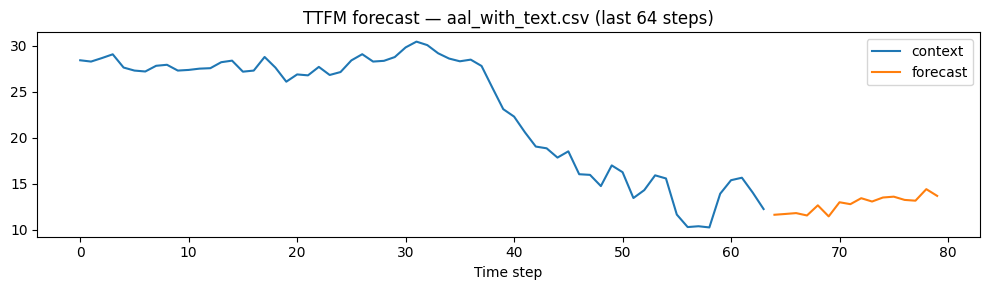

In [4]:
import matplotlib.pyplot as plt

ctx = context[0]
pred = forecast[0, :, 0].detach().cpu().numpy()

plt.figure(figsize=(10, 3))
plt.plot(np.arange(len(ctx)), ctx, label="context")
plt.plot(np.arange(len(ctx), len(ctx) + len(pred)), pred, label="forecast")
plt.legend()
plt.xlabel("Time step")
plt.title("TTFM forecast — aal_with_text.csv (last {} steps)".format(seq_len))
plt.tight_layout()
plt.show()

In [2]:
context = np.random.randn(2, 64).astype(np.float32)  # 2 samples, 64 steps
text = [["report text at t=1", "report text at t=2", ...] for _ in range(2)]  # 2 x 64 strings

forecast = pipeline.predict(context, text, pred_len=16)  # (2, 16, 1)

In [3]:
context

array([[ 5.31440616e-01,  1.29343176e+00, -4.86151040e-01,
        -1.73229411e-01, -5.60065746e-01,  8.92819688e-02,
         9.27631706e-02,  8.57341349e-01,  1.32657439e-01,
        -9.11781311e-01,  2.23543048e-01, -1.09548640e+00,
        -7.01361001e-01,  4.44119871e-01, -1.02093887e+00,
        -6.87184751e-01, -6.61868453e-02, -1.24190557e+00,
         1.95915210e+00,  1.42825532e+00,  8.75296444e-02,
         1.93998415e-03, -3.60205501e-01, -1.02839839e+00,
         3.92637581e-01,  1.89135134e+00,  1.31539428e+00,
         7.03266203e-01,  2.30828375e-01,  1.99844813e+00,
        -8.12519789e-01,  1.10869765e+00, -1.69830069e-01,
        -1.30760443e+00, -1.15294528e+00, -1.91939592e+00,
         7.77640760e-01, -4.26936075e-02,  4.59932625e-01,
         1.50775087e+00,  2.71329194e-01,  2.42107201e+00,
        -1.12324178e+00,  2.05956578e+00, -1.16653144e-01,
        -1.49052426e-01, -2.65709221e-01,  6.48117363e-01,
        -1.54048586e+00, -9.34571743e-01,  4.41034436e-0

In [4]:
context.shape

(2, 64)